In [1]:
import pandas as pd
import numpy as np
import math
import os
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from sklearn.cluster import KMeans
from math import radians, cos, sin, asin, sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('Nassau Candy Distributor.csv')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [5]:
df.shape

(10194, 18)

In [6]:
df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID         int64
Country/Region     object
City               object
State/Province     object
Postal Code        object
Division           object
Region             object
Product ID         object
Product Name       object
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

In [7]:
df['Postal Code'] = pd.to_numeric(df['Postal Code'], errors='coerce')
df['Postal Code'] = df['Postal Code'].astype('Int64')

In [8]:
mode_code = df['Postal Code'].mode()[0]
df['Postal Code'] = df['Postal Code'].fillna(mode_code)

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [10]:
df = df.drop(['Row ID'], axis=1, errors='ignore')

In [11]:
df['Order Date'] = df['Order Date'].astype('datetime64[ns]')
df['Ship Date'] = df['Ship Date'].astype('datetime64[ns]')

In [12]:
df.dtypes

Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID                int64
Country/Region            object
City                      object
State/Province            object
Postal Code                Int64
Division                  object
Region                    object
Product ID                object
Product Name              object
Sales                    float64
Units                      int64
Gross Profit             float64
Cost                     float64
dtype: object

In [13]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 313


In [14]:
df = df.drop_duplicates()

In [15]:
df["lead_time"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [16]:
df.to_csv('NFD_Cleand.csv', index=False)

In [18]:
#Feature Engineer

In [17]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division',
       'Region', 'Product ID', 'Product Name', 'Sales', 'Units',
       'Gross Profit', 'Cost', 'lead_time'],
      dtype='object')

In [18]:
cols = ["Ship Mode","Region","Division","Product Name",'Country/Region','City','State/Province',]

for col in cols:
    df[col] = LabelEncoder().fit_transform(df[col])

In [19]:
df[col] 

0        51
1        13
2        13
3        13
4        43
         ..
10189    34
10190     5
10191     6
10192    34
10193    44
Name: State/Province, Length: 9881, dtype: int64

In [20]:
num_cols = ["Sales","Units","Cost","Gross Profit"]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [21]:
df[num_cols]

,Sales,Units,Cost,Gross Profit
0,-0.653346,-0.806932,-0.487025,-0.744482
1,-0.566175,-0.806932,-0.424627,-0.643178
2,-0.307275,-0.361621,-0.346628,-0.260310
3,-0.278509,-0.361621,-0.288130,-0.255841
4,-0.239282,-0.361621,-0.171133,-0.278187
...,...,...,...,...
10189,-0.370039,-0.361621,-0.264730,-0.430143
10190,-0.611504,-0.806932,-0.541624,-0.631260
10191,-0.278509,-0.361621,-0.288130,-0.255841
10192,1.068291,1.419624,0.842843,1.181778


In [22]:
df.head(2)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,lead_time
0,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,3,103800,1,211,51,77095,0,2,CHO-MIL-31000,10,-0.653346,-0.806932,-0.744482,-0.487025,851
1,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-01-07,3,112326,1,327,13,60540,0,2,CHO-TRI-54000,12,-0.566175,-0.806932,-0.643178,-0.424627,646


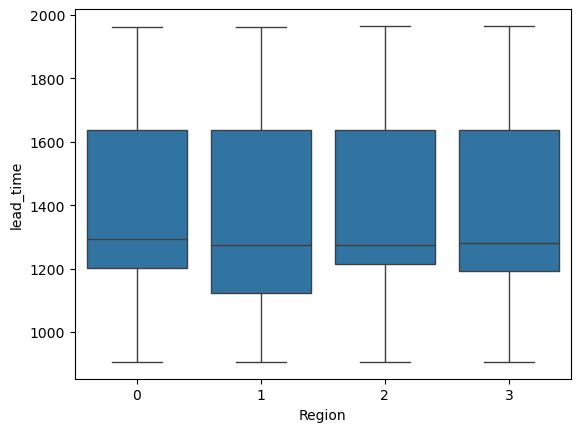

In [26]:
sns.boxplot(x="Region",y="lead_time",data=df)
plt.show()

<Axes: xlabel='Ship Mode', ylabel='lead_time'>

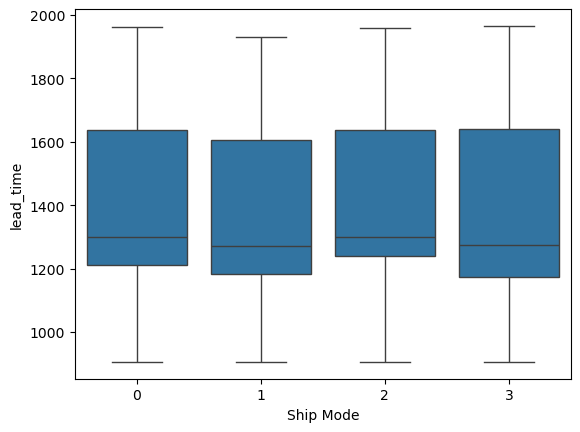

In [27]:
sns.boxplot(x="Ship Mode",y="lead_time",data=df)

In [25]:
lower_limit = df['lead_time'].quantile(0.05)
df['lead_time'] = df['lead_time'].clip(lower=lower_limit)

In [28]:
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,lead_time
0,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,3,103800,1,211,51,77095,0,2,CHO-MIL-31000,10,-0.653346,-0.806932,-0.744482,-0.487025,906
1,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-01-07,3,112326,1,327,13,60540,0,2,CHO-TRI-54000,12,-0.566175,-0.806932,-0.643178,-0.424627,906
2,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-01-07,3,112326,1,327,13,60540,0,2,CHO-NUT-13000,11,-0.307275,-0.361621,-0.260310,-0.346628,906
3,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-01-07,3,112326,1,327,13,60540,0,2,CHO-SCR-58000,13,-0.278509,-0.361621,-0.255841,-0.288130,906
4,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-05-07,3,141817,1,380,43,19143,0,0,CHO-TRI-54000,12,-0.239282,-0.361621,-0.278187,-0.171133,906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,US-2024-143259-CHO-MIL-31000,2025-12-30,2030-06-26,3,143259,1,335,34,10009,0,0,CHO-MIL-31000,10,-0.370039,-0.361621,-0.430143,-0.264730,1639
10190,US-2024-115427-CHO-NUT-13000,2025-12-30,2030-06-26,3,115427,1,150,5,94533,0,3,CHO-NUT-13000,11,-0.611504,-0.806932,-0.631260,-0.541624,1639
10191,US-2024-156720-CHO-SCR-58000,2025-12-30,2030-06-26,3,156720,1,272,6,80538,0,3,CHO-SCR-58000,13,-0.278509,-0.361621,-0.255841,-0.288130,1639
10192,US-2024-143259-CHO-TRI-54000,2025-12-30,2030-06-26,3,143259,1,335,34,10009,0,0,CHO-TRI-54000,12,1.068291,1.419624,1.181778,0.842843,1639


In [29]:
X = df.drop(['Order ID', 'Order Date', 'Ship Date', 'lead_time', 'Product ID'], axis=1)
y = df['lead_time']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Training and Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)

In [30]:
model

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [32]:
predictions = model.predict(X_test)

In [35]:
predictions

array([1321.65255192, 1346.09683292, 1370.19654199, ..., 1373.96186127,
       1490.29920493, 1323.02454005])

In [36]:
print(f"--- {name} Evaluation ---")
print(f"MAE: {mean_absolute_error(y_test, predictions):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.2f}")
print(f"R2 Score: {r2_score(y_test, predictions):.2f}\n")

--- Gradient Boosting Evaluation ---
MAE: 229.47
RMSE: 278.28
R2 Score: 0.04



In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dictionary to store results for comparison
results = {}

# Training and Evaluation
for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # Store and Print scores
    results[name] = r2
    print(f"--- {name} Performance ---")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")
    print("-" * 30)

# Identify the best model based on R2 Score
best_model_name = max(results, key=results.get)
print(f"\n🏆 The Best Model is: {best_model_name} with an R2 of {results[best_model_name]:.4f}")

--- Linear Regression Performance ---
MAE: 235.75
RMSE: 284.35
R2 Score: -0.0041
------------------------------
--- Random Forest Performance ---
MAE: 187.79
RMSE: 238.25
R2 Score: 0.2951
------------------------------
--- Gradient Boosting Performance ---
MAE: 229.47
RMSE: 278.28
R2 Score: 0.0383
------------------------------

🏆 The Best Model is: Random Forest with an R2 of 0.2951


In [38]:
model1 = RandomForestRegressor(oob_score=True, random_state=42)
model1.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [39]:
X_test

,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product Name,Sales,Units,Gross Profit,Cost
4287,1,108504,1,466,11,30080,0,1,13,-0.592326,-0.806932,-0.628281,-0.502625
5984,2,147256,1,95,26,65203,0,2,10,0.763191,1.419624,0.827215,0.624448
3109,2,151435,1,237,18,70506,0,1,9,-0.906144,-1.252244,-1.015618,-0.697620
753,2,109904,1,335,34,10009,0,0,11,-0.307275,-0.361621,-0.260310,-0.346628
7666,2,117401,1,472,26,65807,0,2,10,0.763191,1.419624,0.827215,0.624448
...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,2,141838,1,446,5,94122,0,3,10,-0.086731,0.083690,-0.115803,-0.042436
5785,3,119641,1,180,57,54302,0,2,10,-0.653346,-0.806932,-0.744482,-0.487025
489,2,164224,1,2,39,44312,0,0,12,0.087612,0.083690,0.086804,0.082361
7305,0,147886,1,150,5,94533,0,3,13,0.035309,0.083690,0.116599,-0.073635


In [40]:
y_test

4287    1183
5984    1509
3109    1303
753     1082
7666    1668
        ... 
262      909
5785    1273
489      906
7305    1638
8289    1698
Name: lead_time, Length: 1977, dtype: int64

In [72]:
import joblib
joblib.dump(model1, 'data_scaler.pkl')

['data_scaler.pkl']